# 07 — Milestone 2 Plots

Single notebook that regenerates the four static plots referenced in [`presentation/milestone2.tex`](../presentation/milestone2.tex):

1. Brent spot + curated events, post-COVID → `plots/milestone2/brent_events_postcovid.png`
2. Donor co-movement side-by-side (21 audited donors per focal event) → `plots/milestone2/donors_audited_side_by_side.png`
3. Observed vs synthetic ensemble side-by-side → `plots/milestone2/ensemble_paths_side_by_side.png`
4. Donor importance heatmap (per-model, per-event) → `plots/milestone2/donor_importance_heatmap.png`

Plots 1 and 2 reproduce static charts originally built in [`01_EDA.ipynb`](01_EDA.ipynb). Plots 3 and 4 are new for the deck.

**Prereq:** run [`02_Fit_Models.ipynb`](02_Fit_Models.ipynb) first so the fits exist in `data/results/{event}/preferred/shared/{model}/fit.pkl`. Plots 3 and 4 fail gracefully (empty panels) if a fit is missing.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from lib.config import DONOR_POOL_VARIANT
from lib.data import load_fit

DATA = ROOT / 'data'
PLOTS_DIR = ROOT / 'plots' / 'milestone2'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------- shared data ----------
brent = (pd.read_csv(DATA / 'brent_spot.csv', parse_dates=['Date'])
           .rename(columns={'Date': 'date', 'Price': 'Brent'})
           .set_index('date').sort_index().dropna())
donors = pd.read_parquet(DATA / 'donors.parquet')
events = pd.read_csv(DATA / 'historical_events.csv', parse_dates=['date'])

# ---------- shared constants ----------
WINDOW = 'preferred'
VARIANT = DONOR_POOL_VARIANT   # 'shared' (21-donor)

CATEGORY_COLOR = {
    'supply':      '#d62728',  # red
    'policy':      '#9467bd',  # purple
    'geopolitics': '#ff7f0e',  # orange
    'demand':      '#1f77b4',  # blue
}

AUDITED_DONORS = [
    'Silver', 'Platinum', 'Gold',
    'Coffee', 'Sugar', 'Cotton', 'LiveCattle',
    'SP500', 'WorldEq', 'Nikkei',
    'AUD', 'JPY', 'CHF', 'CNY', 'INR', 'KRW', 'ZAR', 'MXN',
    'TLT', 'HYG',
    'VIX',
]

DONOR_CATEGORIES = {
    'Metals':        ['Silver', 'Platinum', 'Gold'],
    'Agriculturals': ['Coffee', 'Sugar', 'Cotton', 'LiveCattle'],
    'Equities':      ['SP500', 'WorldEq', 'Nikkei'],
    'FX':            ['AUD', 'JPY', 'CHF', 'CNY', 'INR', 'KRW', 'ZAR', 'MXN'],
    'Rates/credit':  ['TLT', 'HYG'],
    'Volatility':    ['VIX'],
}

FOCAL_EVENTS = [
    {'name': 'Russia invades Ukraine',
     'slug': 'russia',
     'T0':        pd.Timestamp('2022-02-24'),
     'pre_start': pd.Timestamp('2020-07-01'),
     'post_end':  pd.Timestamp('2022-09-30')},
    {'name': 'Strait of Hormuz crisis',
     'slug': 'hormuz',
     'T0':        pd.Timestamp('2026-02-01'),
     'pre_start': pd.Timestamp('2024-06-01'),
     'post_end':  pd.Timestamp('2026-05-01')},
]

MODELS = ['convex_scm', 'ascm', 'elastic_net', 'xgboost', 'bayesian_ridge']
MODEL_DISPLAY = {
    'convex_scm':     'Convex SCM',
    'ascm':           'ASCM',
    'elastic_net':    'Elastic-net',
    'xgboost':        'XGBoost',
    'bayesian_ridge': 'Bayesian Ridge',
}
MODEL_COLORS = {
    'convex_scm':     '#1f77b4',
    'ascm':           '#ff7f0e',
    'elastic_net':    '#2ca02c',
    'xgboost':        '#d62728',
    'bayesian_ridge': '#9467bd',
}

print(f'Brent:  {brent.shape}, {brent.index.min().date()} → {brent.index.max().date()}')
print(f'Donors: {donors.shape}, audited: {len(AUDITED_DONORS)}')
print(f'Events: {len(events)}')
print(f'Output: {PLOTS_DIR}')

Brent:  (6679, 1), 2000-01-04 → 2026-04-27
Donors: (5492, 33), audited: 21
Events: 22
Output: /Users/cherrylchico/Desktop/BSE/T3/Thesis/Brent_Analysis/plots/milestone2
Last run: 2026-05-26 01:21:23


## Plot 1 — Brent spot + curated events, post-COVID

Saved: /Users/cherrylchico/Desktop/BSE/T3/Thesis/Brent_Analysis/plots/milestone2/brent_events_postcovid.png


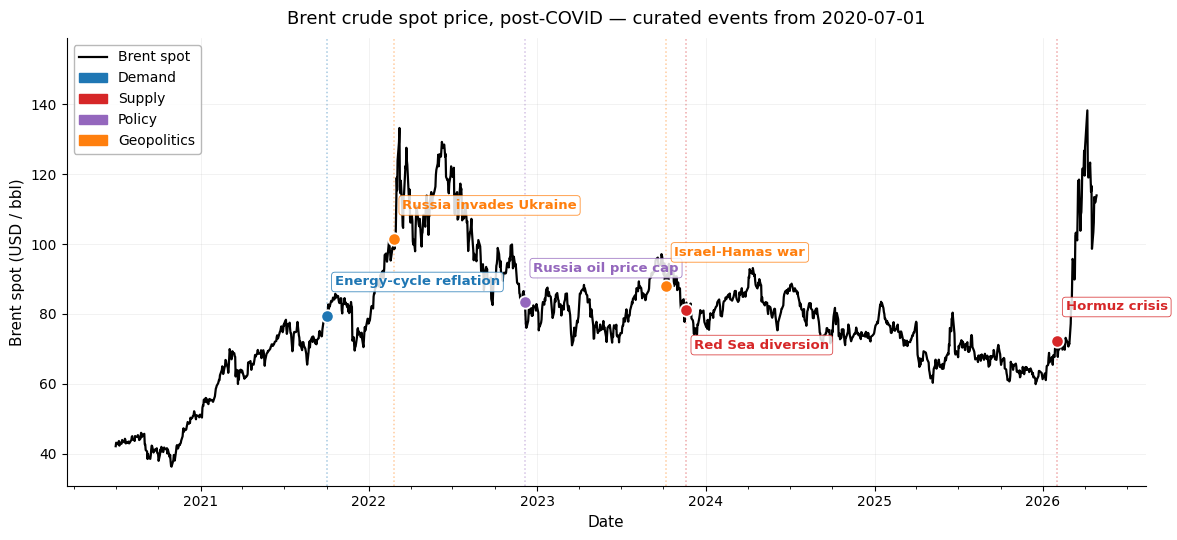

Last run: 2026-05-26 01:21:24


In [2]:
POST_COVID_START = pd.Timestamp('2020-07-01')

def price_at(date, series):
    s = series.dropna()
    if date < s.index.min() or date > s.index.max():
        return np.nan
    return float(s.loc[:date].iloc[-1])

ev = events.copy()
ev['price'] = ev['date'].map(lambda d: price_at(d, brent['Brent']))
ev = ev.dropna(subset=['price'])

brent_post = brent.loc[POST_COVID_START:]
ev_post = ev[ev['date'] >= POST_COVID_START].copy().sort_values('date').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(brent_post.index, brent_post['Brent'], color='black', linewidth=1.6, zorder=2)

# Stagger labels for clustered events
label_dy = []
last_date = None
for _, e in ev_post.iterrows():
    if last_date is not None and (e['date'] - last_date).days < 90:
        label_dy.append(-28 if label_dy[-1] > 0 else 22)
    else:
        label_dy.append(22)
    last_date = e['date']

for (_, e), dy in zip(ev_post.iterrows(), label_dy):
    color = CATEGORY_COLOR[e['category']]
    ax.axvline(x=e['date'], color=color, linestyle=':', alpha=0.4, linewidth=1.1, zorder=1)
    ax.scatter([e['date']], [e['price']], color=color, s=80, zorder=5,
               edgecolor='white', linewidth=1.3)
    ax.annotate(e['label'], xy=(e['date'], e['price']), xytext=(6, dy),
                textcoords='offset points', fontsize=9.5, color=color,
                fontweight='semibold',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor=color, alpha=0.85, linewidth=0.6))

handles = [Line2D([0], [0], color='black', linewidth=1.6, label='Brent spot')]
for cat in ['demand', 'supply', 'policy', 'geopolitics']:
    if cat in ev_post['category'].unique():
        handles.append(Patch(color=CATEGORY_COLOR[cat], label=cat.capitalize()))
ax.legend(handles=handles, loc='upper left', frameon=True, framealpha=0.92,
          fontsize=10, edgecolor='0.7')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Brent spot (USD / bbl)', fontsize=11)
ax.set_title(f'Brent crude spot price, post-COVID — curated events from {POST_COVID_START.date()}',
             fontsize=13, pad=10)
ax.grid(alpha=0.22, linestyle='-', linewidth=0.5)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylim(brent_post['Brent'].min() * 0.85, brent_post['Brent'].max() * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()

out = PLOTS_DIR / 'brent_events_postcovid.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

## Plot 2 — Donor co-movement side-by-side (21 audited donors per focal event)

Saved: /Users/cherrylchico/Desktop/BSE/T3/Thesis/Brent_Analysis/plots/milestone2/donors_audited_side_by_side.png


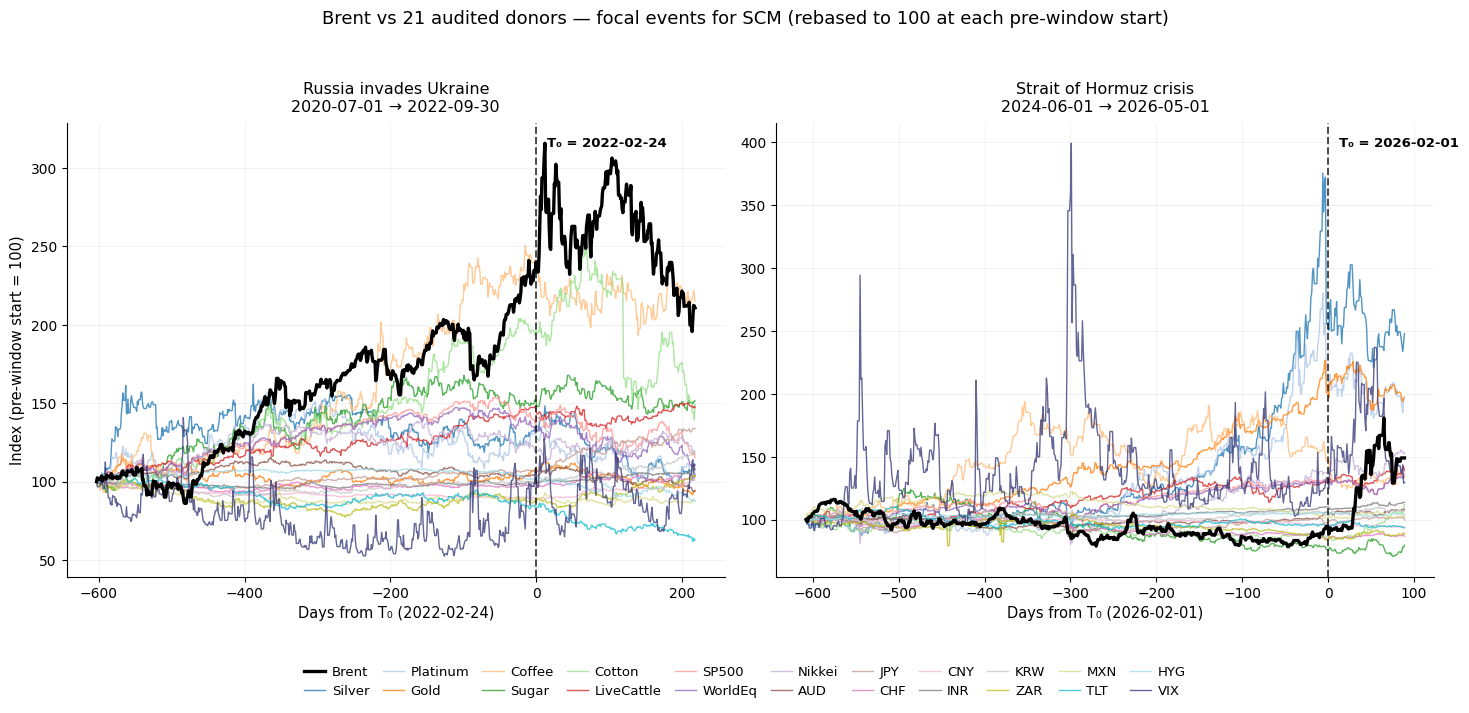

Last run: 2026-05-26 01:21:26


In [3]:
def build_event_panel(event, brent, donors, audited):
    """Pre-window start to post_end, rebased to 100 at first in-window date."""
    data = (brent[['Brent']].join(donors[audited], how='outer')
                            .sort_index()
                            .loc[event['pre_start']:event['post_end']])
    data = data.ffill(limit=5).dropna()
    if data.empty:
        return None
    base = data.iloc[0]
    norm = 100 * data.divide(base)
    norm['_days_from_T0'] = (norm.index - event['T0']).days
    return norm

cmap20  = plt.get_cmap('tab20').colors
cmap20b = plt.get_cmap('tab20b').colors
palette = list(cmap20) + list(cmap20b)
color_map = dict(zip(AUDITED_DONORS, palette[:len(AUDITED_DONORS)]))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

legend_handles, legend_labels = [], []

for i, (ax, event) in enumerate(zip(axes, FOCAL_EVENTS)):
    panel = build_event_panel(event, brent, donors, AUDITED_DONORS)
    x = panel['_days_from_T0'].values
    for col in AUDITED_DONORS:
        line, = ax.plot(x, panel[col].values, color=color_map[col],
                        linewidth=1.0, alpha=0.78, label=col)
        if i == 0:
            legend_handles.append(line)
            legend_labels.append(col)
    brent_line, = ax.plot(x, panel['Brent'].values, color='black',
                          linewidth=2.4, label='Brent', zorder=10)
    if i == 0:
        legend_handles.insert(0, brent_line)
        legend_labels.insert(0, 'Brent')

    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.4, alpha=0.7, zorder=8)
    _, ymax = ax.get_ylim()
    ax.annotate(f"T₀ = {event['T0'].date()}", xy=(0, ymax), xytext=(8, -10),
                textcoords='offset points', fontsize=9.5,
                ha='left', va='top', fontweight='semibold')
    ax.set_xlabel(f"Days from T₀ ({event['T0'].date()})", fontsize=10.5)
    ax.set_title(f"{event['name']}\n{event['pre_start'].date()} → {event['post_end'].date()}",
                 fontsize=11.5, pad=8)
    ax.grid(alpha=0.22, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Index (pre-window start = 100)', fontsize=10.5)

fig.legend(legend_handles, legend_labels,
           loc='lower center', bbox_to_anchor=(0.5, -0.005),
           frameon=False, fontsize=9.5, ncol=11,
           columnspacing=1.0, handlelength=1.6, handletextpad=0.5)

fig.suptitle('Brent vs 21 audited donors — focal events for SCM '
             '(rebased to 100 at each pre-window start)',
             fontsize=13, y=0.995)
fig.tight_layout(rect=[0, 0.10, 1, 0.96])

out = PLOTS_DIR / 'donors_audited_side_by_side.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

## Plot 3 — Observed vs synthetic ensemble, side-by-side

Loads each model's saved fit and overlays observed Brent (USD / bbl) against the five synthetic counterfactuals. Vertical dashed line marks $T_0$.

Saved: /Users/cherrylchico/Desktop/BSE/T3/Thesis/Brent_Analysis/plots/milestone2/ensemble_paths_side_by_side.png


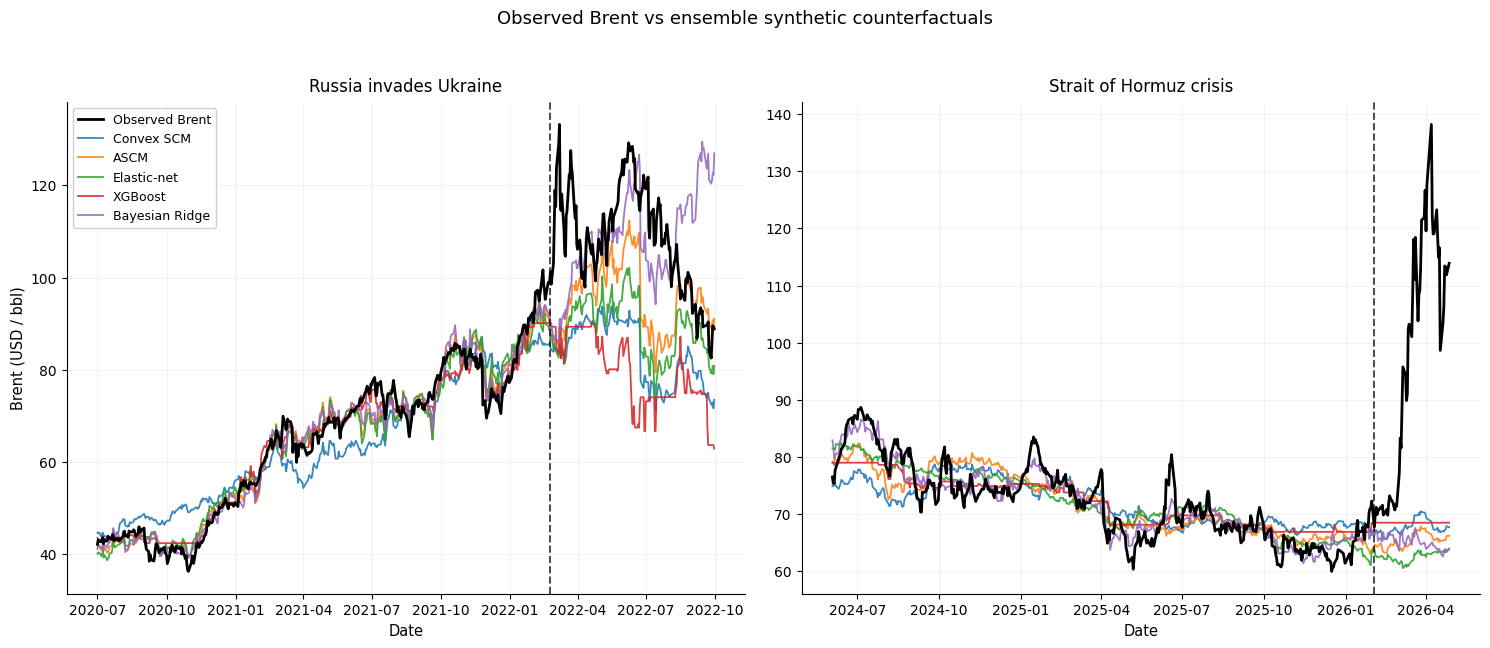

Last run: 2026-05-26 01:21:27


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

for ax, event in zip(axes, FOCAL_EVENTS):
    fits = {}
    for model in MODELS:
        f = load_fit(event['slug'], WINDOW, model, variant=VARIANT)
        if f is not None:
            fits[model] = f

    if not fits:
        ax.text(0.5, 0.5, 'No fits found', transform=ax.transAxes, ha='center', va='center')
        continue

    any_fit = next(iter(fits.values()))
    t_start = any_fit['t_pre_start']
    t_end   = any_fit['gap'].index.max()

    # Observed Brent in USD/bbl
    obs = brent.loc[t_start:t_end, 'Brent']
    ax.plot(obs.index, obs.values, color='black', linewidth=2.0,
            label='Observed Brent', zorder=10)

    # Synthetic paths (convert from log to USD/bbl)
    for model, f in fits.items():
        synth_usd = np.exp(f['synth'])
        ax.plot(synth_usd.index, synth_usd.values, color=MODEL_COLORS[model],
                linewidth=1.3, alpha=0.88, label=MODEL_DISPLAY[model])

    ax.axvline(x=event['T0'], color='black', linestyle='--',
               linewidth=1.4, alpha=0.7, zorder=8)
    ax.set_xlabel('Date', fontsize=10.5)
    ax.set_title(event['name'], fontsize=12, pad=8)
    ax.grid(alpha=0.22, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Brent (USD / bbl)', fontsize=10.5)
axes[0].legend(loc='upper left', frameon=True, fontsize=9, framealpha=0.92)

fig.suptitle('Observed Brent vs ensemble synthetic counterfactuals',
             fontsize=13, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.96])

out = PLOTS_DIR / 'ensemble_paths_side_by_side.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

## Plot 4 — Donor importance heatmap

Per-model donor importance, **normalized within each column to sum to 1**. Cell colour = donor's share of model's total importance. Rows grouped by category (Metals → Agriculturals → Equities → FX → Rates/credit → Volatility) with thin separator lines.

Importance metric per model (see [docs/methodology.md §4](../docs/methodology.md)):
- **Convex SCM, ASCM**: convex weight $w_j$
- **Elastic-net**: $|\hat\beta_j|$
- **XGBoost**: feature importance (gain-based, from `xgb.feature_importances_`)
- **Bayesian Ridge**: $|\hat\beta_j|$ (PIP proxy)

Within-column normalization makes the colour scale visually comparable across models despite the underlying metric differences.

In [ ]:
def normalized_importance(fit, donors_list):
    """|weights| reindexed to donors_list, normalized to sum to 1."""
    w = fit['weights']
    imp = w.reindex(donors_list).fillna(0).abs()
    total = imp.sum()
    return imp / total if total > 0 else imp

# Order donors by category for the heatmap rows
ordered_donors = []
category_boundaries = []   # row indices where a new category starts (excluding first)
for cat, members in DONOR_CATEGORIES.items():
    if ordered_donors:
        category_boundaries.append(len(ordered_donors))
    ordered_donors.extend(members)

# Wider layout so model names fit horizontally (no rotation)
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))

for ax, event in zip(axes, FOCAL_EVENTS):
    matrix = np.zeros((len(ordered_donors), len(MODELS)))
    for j, model in enumerate(MODELS):
        f = load_fit(event['slug'], WINDOW, model, variant=VARIANT)
        if f is None:
            continue
        matrix[:, j] = normalized_importance(f, ordered_donors).values

    im = ax.imshow(matrix, cmap='Blues', aspect='auto', vmin=0)

    ax.set_yticks(range(len(ordered_donors)))
    ax.set_yticklabels(ordered_donors, fontsize=8.5)
    ax.set_xticks(range(len(MODELS)))
    ax.set_xticklabels([MODEL_DISPLAY[m] for m in MODELS],
                       rotation=0, ha='center', fontsize=9.5)

    # Category boundary lines
    for bnd in category_boundaries:
        ax.axhline(y=bnd - 0.5, color='gray', linewidth=0.8, alpha=0.6)

    # Cell value text for non-trivial weights
    vmax = matrix.max() if matrix.max() > 0 else 1.0
    for i in range(len(ordered_donors)):
        for j in range(len(MODELS)):
            v = matrix[i, j]
            if v > 0.04:
                color = 'white' if v > 0.5 * vmax else 'black'
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=7.5, color=color)

    ax.set_title(event['name'], fontsize=12, pad=8)
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, shrink=0.85)

fig.suptitle('Donor importance per model --- within-column normalized share',
             fontsize=13, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.97])

out = PLOTS_DIR / 'donor_importance_heatmap.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()
